<a href="https://colab.research.google.com/github/RiyaH2020/Applied-Machine-Learning/blob/main/Assignment_5/Task_1_Chicken_Duck/MDS202431_Assignment_5_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Name: Riya Shyam Huddar

### Roll No.: MDS202431

### AML Assignment 5 Task 1 : Transfer Learning for image data using CNN

In [2]:
# Imports
import os
import torch
import zipfile
import shutil
import random
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch

### Transfer Learning for Image Classification

### Objective

The goal of this assignment is to use transfer learning with a pre-trained CNN to classify images of chickens and ducks.

### Task

- Use a dataset of chicken and duck images  
- Train a pre-trained model for binary classification  
- Evaluate the model using a classification report  

### Model Choice

A pre-trained ResNet18 model was used due to its strong performance, simplicity, and suitability for transfer learning on small datasets.

In [4]:
print(torch.cuda.is_available())

True


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Initial Steps

Next we create the directory structure to store our data.

In [4]:
target_base = "/content/drive/MyDrive/duck_chicken_dataset"

folders = [
    "train/chicken", "train/duck",
    "val/chicken", "val/duck"
]

for f in folders:
    os.makedirs(os.path.join(target_base, f), exist_ok=True)

print("Folders created")

Folders created


In [5]:
base = "/content/drive/MyDrive/duck_chicken_dataset"

intermediate = base + "/all_data"

os.makedirs(intermediate + "/chicken", exist_ok=True)
os.makedirs(intermediate + "/duck", exist_ok=True)

print("Intermediate folders created")

Intermediate folders created


In [6]:
base = "/content/drive/MyDrive/duck_chicken_dataset"

os.makedirs(base + "/test/chicken", exist_ok=True)
os.makedirs(base + "/test/duck", exist_ok=True)

print("Test folders created")

Test folders created


### 2. Dataset Collection and Preparation

The dataset used in this project was obtained from Kaggle:

- Dataset: Chicken Images Classification Dataset  
- Source: https://www.kaggle.com/datasets/roudranildas/chicken-images-classification-dataset  

### Original Dataset Distribution

The dataset contains images organized into train, validation, and test splits:

- Duck images:
  - Train: 622  
  - Validation: 109  
  - Test: 310  

- Chicken images:
  - Train: 275  
  - Validation: 52  
  - Test: 172  

### Data Selection and Cleaning

To meet the assignment requirements and improve data quality, a subset of the dataset was selected:

- A total of **150 images per class** (chicken and duck) were chosen  
- Invalid or corrupted files were removed  
- Manual inspection was performed to remove:
  - Irrelevant images (e.g., toys, cartoons)  
  - Low-quality or ambiguous samples  

The selected images were first stored in intermediate folders on Google Drive to preserve a clean copy of the curated dataset.
From the intermediate dataset, images were shuffled and split into training, validation, and test sets.

In [ ]:
!kaggle datasets download -d roudranildas/chicken-images-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/roudranildas/chicken-images-classification-dataset
License(s): unknown
chicken-images-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
with zipfile.ZipFile("chicken-images-classification-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [ ]:
base_path = "data/data"

for category in ["duck-images", "chicken-images"]:
    print(f"\n--- {category} ---")
    for split in ["train", "val", "test"]:
        path = os.path.join(base_path, category, "data", split)
        files = os.listdir(path)
        print(split, ":", len(files))


--- duck-images ---
train : 622
val : 109
test : 310

--- chicken-images ---
train : 275
val : 52
test : 172


In [7]:
print("Chicken:", len(os.listdir(intermediate + "/chicken")))
print("Duck:", len(os.listdir(intermediate + "/duck")))

Chicken: 150
Duck: 150


In [9]:
base = "/content/drive/MyDrive/duck_chicken_dataset"

# Step 1 - Reset target folders
for split in ["train", "val", "test"]:
    for cls in ["chicken", "duck"]:
        path = os.path.join(base, split, cls)

        if os.path.exists(path):
            shutil.rmtree(path)

        os.makedirs(path, exist_ok=True)

print("Target folders reset")

# Step 2 - Function to split and copy
def split_and_copy(class_name):
    source = os.path.join(base, "all_data", class_name)
    files = os.listdir(source)

    random.shuffle(files)

    train_files = files[:100]
    val_files   = files[100:125]
    test_files  = files[125:150]

    for f in train_files:
        shutil.copy(os.path.join(source, f),
                    os.path.join(base, "train", class_name, f))

    for f in val_files:
        shutil.copy(os.path.join(source, f),
                    os.path.join(base, "val", class_name, f))

    for f in test_files:
        shutil.copy(os.path.join(source, f),
                    os.path.join(base, "test", class_name, f))

    print(f"{class_name} split done")

# Step 3 - Run for both classes
split_and_copy("chicken")
split_and_copy("duck")

print("All splits completed")

Target folders reset
chicken split done
duck split done
All splits completed


### Final Dataset Distribution

- Training:
  - Chicken: 100 images
  - Duck: 100 images
- Validation:
  - Chicken: 25 images
  - Duck: 25 images
- Test:
  - Chicken: 25 images
  - Duck: 25 images

The dataset is balanced across all splits and consists of manually curated samples, improving the reliability and generalization of the model.

In [7]:
base = "/content/drive/MyDrive/duck_chicken_dataset"

splits = ["train", "val", "test"]
classes = ["chicken", "duck"]

summary = {}

for split in splits:
    split_path = os.path.join(base, split)
    summary[split] = {}

    for cls in classes:
        cls_path = os.path.join(split_path, cls)

        if os.path.exists(cls_path):
            count = len(os.listdir(cls_path))
        else:
            count = 0

        summary[split][cls] = count

# Print summary
print("Dataset Summary:\n")

total = 0
for split in splits:
    print(f"{split.upper()} SET:")
    for cls in classes:
        count = summary[split][cls]
        print(f"  {cls}: {count}")
        total += count
    print()

print("Total images:", total)

Dataset Summary:

TRAIN SET:
  chicken: 100
  duck: 100

VAL SET:
  chicken: 25
  duck: 25

TEST SET:
  chicken: 25
  duck: 25

Total images: 300


### 3. Data Preprocessing

Before feeding images into the neural network, preprocessing transformations are applied to ensure compatibility with pretrained models.

The following transformations are used:

- **Resize (224 × 224)**  
  Ensures all images have a uniform size required by pretrained CNN architectures.

- **Random Horizontal Flip (training only)**  
  Introduces data augmentation to improve model generalization.

- **Conversion to Tensor**  
  Converts images into PyTorch tensors and scales pixel values to [0, 1].

- **Normalization**  
  Applies ImageNet mean and standard deviation to match the distribution used during pretraining.

Separate transformations are defined for training and evaluation datasets (validation and test) to ensure consistent evaluation.

In [8]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Dataset Loading

The dataset is loaded using PyTorch's `ImageFolder` class, which automatically assigns labels based on directory structure.

Directory structure:

- `train/chicken` -> label 0  
- `train/duck` -> label 1  
- `val/chicken` and `val/duck` for validation  
- `test/chicken` and `test/duck` for final evaluation  

Each image is mapped to its corresponding class label based on its folder name.


In [9]:
from torchvision import datasets

train_data = datasets.ImageFolder(
    root="/content/drive/MyDrive/duck_chicken_dataset/train",
    transform=train_transforms
)

val_data = datasets.ImageFolder(
    root="/content/drive/MyDrive/duck_chicken_dataset/val",
    transform=eval_transforms
)

test_data = datasets.ImageFolder(
    root="/content/drive/MyDrive/duck_chicken_dataset/test",
    transform=eval_transforms
)

In [10]:
print(train_data.class_to_idx)

{'chicken': 0, 'duck': 1}


In [11]:
print(len(train_data), len(val_data), len(test_data))

200 50 50


### Class Distribution

The distribution of images across classes and dataset splits (training, validation, and test) is visualized to verify dataset balance.

A balanced dataset ensures that the model does not develop bias toward any particular class and helps achieve fair and reliable performance across all classes.

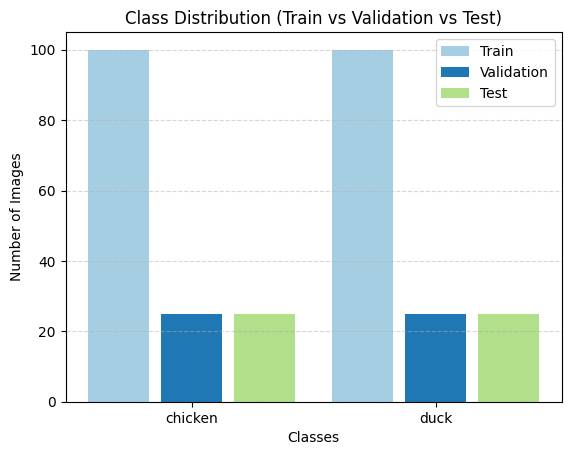

In [12]:
base = "/content/drive/MyDrive/duck_chicken_dataset"

splits = ["train", "val", "test"]
classes = ["chicken", "duck"]

data = {split: [] for split in splits}

for split in splits:
    for cls in classes:
        path = os.path.join(base, split, cls)
        count = len(os.listdir(path))
        data[split].append(count)

# Plot
x = range(len(classes))

plt.figure()

plt.bar([i - 0.3 for i in x], data["train"], width=0.25, label="Train", color="#a6cee3")
plt.bar([i for i in x], data["val"], width=0.25, label="Validation", color="#1f78b4")
plt.bar([i + 0.3 for i in x], data["test"], width=0.25, label="Test", color="#b2df8a")

plt.xticks(x, classes)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution (Train vs Validation vs Test)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### 4. Data Loading and Batching

The `DataLoader` class is used to efficiently load data during training, validation, and testing.

Key configurations:

- **Batch size = 32**  
  Enables efficient computation and stable gradient updates.

- **Shuffle (training only)**  
  Randomizes data order to prevent the model from learning sequence patterns.

- **No shuffle (validation and test)**  
  Ensures consistent and reproducible evaluation.

The DataLoader provides batches of images and labels, which are used as input to the neural network during training and evaluation.

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

### Sample Images from Dataset

A few sample images from the training dataset are visualized to understand the data distribution and quality.

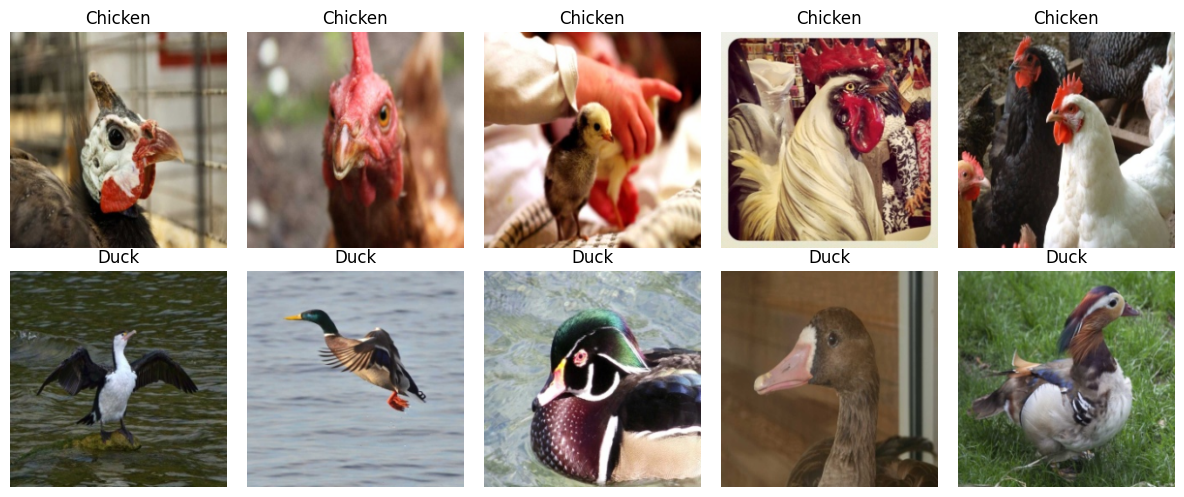

In [36]:
images, labels = next(iter(train_loader))
images = images.cpu()
labels = labels.cpu()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# collect indices
chicken_indices = (labels == 0).nonzero(as_tuple=True)[0][:5]
duck_indices = (labels == 1).nonzero(as_tuple=True)[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# first row: chicken
for i, idx in enumerate(chicken_indices):
    img = images[idx].permute(1, 2, 0).numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[0, i].imshow(img)
    axes[0, i].set_title("Chicken")
    axes[0, i].axis("off")

# second row: duck
for i, idx in enumerate(duck_indices):
    img = images[idx].permute(1, 2, 0).numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)

    axes[1, i].imshow(img)
    axes[1, i].set_title("Duck")
    axes[1, i].axis("off")


plt.tight_layout()
plt.show()

### Data Sanity Check

A sample batch is retrieved from the training DataLoader to verify:

- Correct image dimensions
- Proper batching
- Valid label assignments

Expected tensor shape:  
`[batch_size, channels, height, width] = [32, 3, 224, 224]`

In [14]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
tensor([1, 1, 0, 1, 0, 1, 0, 0, 0, 0])


---

### 5. Transfer Learning using Pretrained CNN

A pretrained convolutional neural network (ResNet18) is used for image classification.

The model is pretrained on the ImageNet dataset, which contains a large number of images across 1000 classes. Transfer learning allows reuse of these learned features for the current task (chicken vs duck classification).

To adapt the model:

- A pretrained ResNet18 model is loaded
- The final fully connected layer is replaced with a new layer having 2 output classes
- The model is moved to the available device (GPU if available, otherwise CPU)

In [15]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

In [16]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [17]:
model.fc = nn.Linear(in_features=512, out_features=2)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(device)

cuda


### Freezing Pretrained Layers

To leverage transfer learning effectively, the pretrained layers of the model are frozen by disabling gradient updates. This preserves the general visual features learned from ImageNet.

Only the final fully connected layer is kept trainable, allowing the model to adapt to the new classification task (chicken vs duck) while reducing the risk of overfitting on a small dataset.

The trainable and frozen parameters are verified by inspecting the `requires_grad` attribute of each layer.

In [19]:
for param in model.parameters():
    param.requires_grad = False

In [20]:
for param in model.fc.parameters():
    param.requires_grad = True

In [21]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer3.0.conv1.weight False
layer3.0.bn1.weight False
layer3.0.bn1.bias False
layer3.0.conv2.weight False
layer3.0.bn2.weight False
layer3.0.bn2.bias False
layer3.0.downsample.0.weight False
layer3.0.downsample.1.weight Fa

### Loss Function

The Cross Entropy Loss function is used for this classification task.

It measures the difference between the predicted class probabilities and the true labels. This loss function is suitable for classification problems and is commonly used with neural networks.

In this case, it is used for binary classification (chicken vs duck) with two output classes.

In [22]:
criterion = nn.CrossEntropyLoss()

### Optimizer

The Adam optimizer is used to update model parameters during training.

Only the parameters of the final fully connected layer are optimized, as the earlier layers are frozen. This reduces computational cost and allows the model to adapt efficiently while preserving pretrained features.

In [23]:
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

### Model Training

The model is trained using the training dataset and evaluated on the validation dataset.

Training involves:
- Forward pass: computing predictions  
- Loss computation: comparing predictions with true labels  
- Backward pass: computing gradients  
- Optimization step: updating model parameters  

Validation is performed after each epoch to monitor model performance on unseen data and track both loss and accuracy.

The test dataset is not used during training and is reserved for final evaluation after the model has been trained.

In [24]:
train_losses = []
val_losses = []
val_accuracies = []

num_epochs = 25

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_accuracy:.4f}")

Epoch [1/25] Train Loss: 0.7144 Val Loss: 0.5815 Val Acc: 0.7000
Epoch [2/25] Train Loss: 0.4643 Val Loss: 0.4291 Val Acc: 0.9200
Epoch [3/25] Train Loss: 0.3506 Val Loss: 0.3112 Val Acc: 0.9600
Epoch [4/25] Train Loss: 0.2735 Val Loss: 0.2695 Val Acc: 0.9200
Epoch [5/25] Train Loss: 0.2361 Val Loss: 0.2653 Val Acc: 0.9600
Epoch [6/25] Train Loss: 0.2296 Val Loss: 0.2051 Val Acc: 0.9400
Epoch [7/25] Train Loss: 0.1993 Val Loss: 0.1903 Val Acc: 0.9600
Epoch [8/25] Train Loss: 0.1468 Val Loss: 0.1840 Val Acc: 0.9600
Epoch [9/25] Train Loss: 0.2211 Val Loss: 0.1614 Val Acc: 0.9800
Epoch [10/25] Train Loss: 0.2862 Val Loss: 0.1742 Val Acc: 0.9400
Epoch [11/25] Train Loss: 0.1079 Val Loss: 0.1986 Val Acc: 0.9400
Epoch [12/25] Train Loss: 0.1440 Val Loss: 0.1814 Val Acc: 0.9400
Epoch [13/25] Train Loss: 0.1093 Val Loss: 0.1414 Val Acc: 0.9800
Epoch [14/25] Train Loss: 0.1138 Val Loss: 0.1452 Val Acc: 0.9600
Epoch [15/25] Train Loss: 0.1409 Val Loss: 0.1384 Val Acc: 0.9400
Epoch [16/25] Train

### Training and Validation Loss Curves

The loss curves illustrate how the model learns over training epochs.

- Both training and validation loss decrease steadily in the initial epochs, indicating effective learning
- The validation loss closely follows the training loss, suggesting good generalization
- There is no significant divergence between the two curves, indicating minimal overfitting

Overall, the model converges well, and the training process is stable.

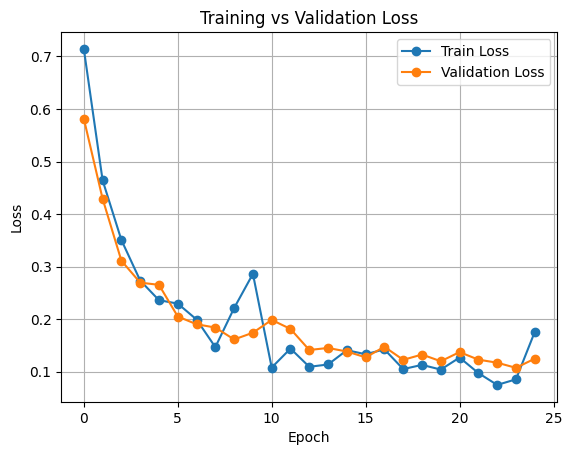

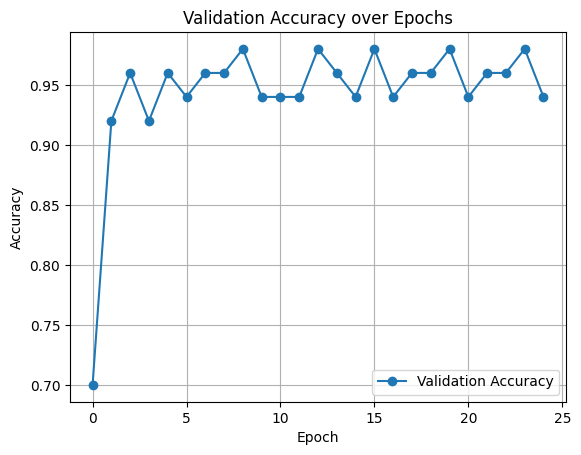

In [25]:
plt.figure()

plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

plt.figure()

plt.plot(val_accuracies, label="Validation Accuracy", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy over Epochs")

plt.legend()
plt.grid()

plt.show()

----

### 6. Model Evaluation

The trained model is evaluated on the **test dataset**, which was not used during training or validation. This provides an unbiased estimate of model performance on unseen data.

The following metrics are used:

- Accuracy  
- Precision  
- Recall  
- F1-score  

### Results Interpretation

- The model achieves an overall accuracy of **92%** on the test set
- Both classes (chicken and duck) have balanced precision and recall values
- The F1-score is consistent across classes, indicating stable performance

The results show that the model generalizes well to unseen data and does not exhibit significant bias toward any class.


In [26]:
from sklearn.metrics import classification_report
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [27]:
print(classification_report(all_labels, all_preds, target_names=["chicken", "duck"]))

              precision    recall  f1-score   support

     chicken       0.96      0.88      0.92        25
        duck       0.89      0.96      0.92        25

    accuracy                           0.92        50
   macro avg       0.92      0.92      0.92        50
weighted avg       0.92      0.92      0.92        50



In [29]:
from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(all_labels, all_preds))

Test Accuracy: 0.92


### Confusion Matrix

The confusion matrix provides a detailed view of the model’s predictions on the test dataset.

- Most samples are correctly classified:
  - 23 chickens correctly predicted as chicken
  - 24 ducks correctly predicted as duck  
- A small number of misclassifications are observed:
  - 3 chickens misclassified as duck  
  - 1 duck misclassified as chicken  

This indicates that the model performs well on both classes, with only minor confusion between them.


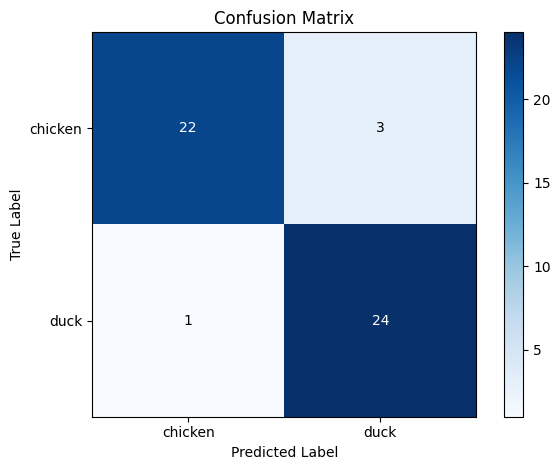

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure()

# better color map
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

classes = ["chicken", "duck"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)


for i in range(len(classes)):
    for j in range(len(classes)):
        color = "white" if cm[i, j] > cm.max()/2 else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

### ROC Curve

The ROC curve illustrates the trade-off between true positive rate and false positive rate across different classification thresholds.

The model achieves an AUC score of **0.98**, indicating excellent ability to distinguish between chicken and duck images.

The curve is close to the top-left corner, showing that the model achieves high true positive rates with low false positive rates across thresholds.

This confirms that the model performs well beyond a fixed decision threshold.

In [31]:
from sklearn.metrics import roc_curve, auc
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class "duck"

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

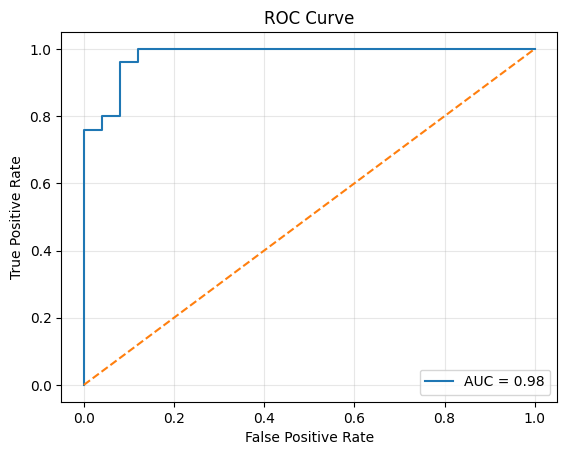

In [32]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.grid(alpha=0.3)
plt.show()

### Misclassified Examples

To better understand model errors, a few misclassified images from the test set are visualized.

These observations suggest that the model may struggle with:
- Similar visual appearances between classes
- Limited variation in the training dataset
- Background or contextual similarities

Overall, the errors are reasonable and highlight challenging edge cases rather than systematic failure.

In [33]:
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            if preds[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_labels.append(labels[i].cpu().item())
                misclassified_preds.append(preds[i].cpu().item())

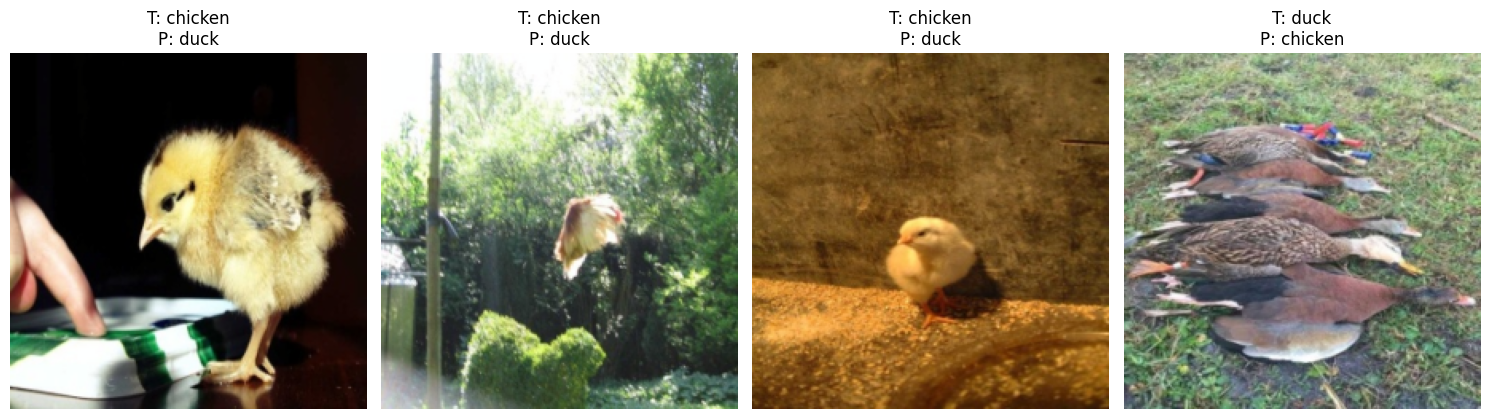

In [34]:
# unnormalize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

num_images = min(6, len(misclassified_images))

fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):
    img = misclassified_images[i].permute(1, 2, 0).numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)

    true_label = "chicken" if misclassified_labels[i] == 0 else "duck"
    pred_label = "chicken" if misclassified_preds[i] == 0 else "duck"

    axes[i].imshow(img)
    axes[i].set_title(f"T: {true_label}\nP: {pred_label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Conclusion

In this task, a pretrained ResNet18 model was used for classifying images of chickens and ducks. The model was chosen due to its proven performance, relatively simple architecture, and suitability for transfer learning on small datasets.

To adapt the model to this task, the final fully connected layer was replaced with a two-class output layer. The pretrained layers were frozen to retain learned features from ImageNet, and only the final layer was trained on the curated dataset. This approach enabled efficient learning while reducing the risk of overfitting.

The model achieved strong performance, with a test accuracy of approximately **92%** and an AUC score of **0.98**. The classification report and confusion matrix indicate balanced performance across both classes, with only minor misclassifications. Analysis of misclassified examples shows that errors occur mainly in visually ambiguous cases.

Overall, the results demonstrate that transfer learning is an effective approach for image classification tasks, especially when working with limited but well-curated data.